# Results Compilation and Figure Generation

Loads pre-computed cross-validation results from `data/model_results/` and
generates all tables and figures used in the paper.

**Inputs:**
- `data/model_results/{model}_{split}.csv`
- `data/models/VARX_9.pkl` (for correlation / trace plots)

**Outputs (all written to `images/`):**
- `images/model_comparison.pdf`
- `images/ar_comparison.pdf`
- `images/correlation_matrices.pdf`

In [77]:
import os
import pickle as pkl
from functools import partial, reduce
from pathlib import Path

import arviz as az
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import xarray as xr
import tqdm

from src.modeling.metrics import summarize

RESULTS_DIR = Path("./data/model_results")
MODEL_DIR = Path("./data/models")
IMAGES_DIR = Path("./images")
IMAGES_DIR.mkdir(exist_ok=True)

## Helpers

In [78]:
def rename_lakes(x):
    return {
        "eri": "Erie",
        "sup": "Superior",
        "mic_hur": "Michigan/Huron",
        "ont": "Ontario",
    }.get(x, x)


def rollup_agg(df, groupings, fn=summarize):
    full_groupings = (
        df.groupby(groupings, observed=False)
        .apply(fn, include_groups=False)
        .reset_index()
    )
    all_groupings = (
        df.groupby(groupings[:-1], observed=False)
        .apply(fn, include_groups=False)
        .reset_index()
    )
    all_groupings[groupings[-1]] = "All"
    return pd.concat(
        [full_groupings, all_groupings.assign(lake="All")], axis=0, ignore_index=True
    ).set_index(groupings)

## Load Data

In [79]:
with open(Path("data") / "y_scaler.pkl", "rb") as f:
    y_scaler = pkl.load(f)


result_files = sorted(RESULTS_DIR.glob("*.csv"))
if not result_files:
    raise FileNotFoundError(
        f"No result CSVs found in {RESULTS_DIR}. Run 02_fit_models.py first."
    )

cv_results = pd.concat(
    [pd.read_csv(f) for f in result_files], axis=0, ignore_index=True
)
cv_results["Date"] = pd.to_datetime(cv_results["Date"])
cv_results = cv_results[cv_results["months_ahead"] <= 12]
print(f"Loaded {len(result_files)} result files, {len(cv_results)} rows total")

Loaded 91 result files, 4368 rows total


## Process: Scale / Unscale Predictions

In [80]:
unscaled_predictions = cv_results[
    [
        "Date",
        "lake",
        "model",
        "mean",
        "lower",
        "upper",
        "true",
        "std",
        "months_ahead",
        "split",
    ]
].melt(id_vars=["Date", "model", "lake", "months_ahead", "split"])

unscaled_predictions["lake"] = pd.Categorical(
    unscaled_predictions["lake"],
    categories=["sup", "mic_hur", "eri", "ont"],
    ordered=True,
)

grped_data = (
    unscaled_predictions.pivot_table(
        index=["Date", "model", "variable", "months_ahead", "split"],
        columns=["lake"],
        values="value",
    )
    .reset_index()
    .groupby("variable")
)

scaled_data = []
unscaled_data = []
for var_name, df in grped_data:
    scaled_sub_df = df.copy()
    df[["sup", "mic_hur", "eri", "ont"]] = y_scaler.inverse_transform(
        df[["sup", "mic_hur", "eri", "ont"]]
    )
    df = df.melt(
        id_vars=["Date", "model", "months_ahead", "split"],
        value_vars=["sup", "mic_hur", "eri", "ont"],
        var_name="lake",
        value_name=var_name,
    ).set_index(["Date", "model", "lake", "months_ahead", "split"])
    unscaled_data.append(df)
    scaled_sub_df = scaled_sub_df.melt(
        id_vars=["Date", "model", "months_ahead", "split"],
        value_vars=["sup", "mic_hur", "eri", "ont"],
        var_name="lake",
        value_name=var_name,
    ).set_index(["Date", "model", "lake", "months_ahead", "split"])
    scaled_data.append(scaled_sub_df)

scaled_data = reduce(
    partial(pd.merge, left_index=True, right_index=True), scaled_data
).reset_index()
unscaled_data = reduce(
    partial(pd.merge, left_index=True, right_index=True), unscaled_data
).reset_index()

print(f"scaled_data: {scaled_data.shape}, unscaled_data: {unscaled_data.shape}")

scaled_data: (4368, 10), unscaled_data: (4368, 10)


## Tables

In [81]:
print("=== Per-lake performance ===")
display(
    scaled_data.groupby(["lake", "model"])
    .apply(summarize, include_groups=False)
    .reset_index()
)

=== Per-lake performance ===


,lake,model,rmse,mae,mape,variance,bias,coverage,interval_len,crps,N,r2
0,eri,BoostedTrees,0.492609,0.394468,2.576868,0.239347,0.057592,0.858333,2.126489,0.277090,120.0,0.642001
1,eri,Default,0.687604,0.556297,2.068891,0.467661,0.071680,0.875000,2.229041,0.386519,120.0,0.100022
2,eri,GP_Matern,0.465157,0.361101,5.124776,0.209346,0.083814,0.916667,1.573096,0.257481,120.0,0.751415
3,eri,MVT,0.681559,0.547905,11.449420,0.464355,0.012944,0.916667,2.351827,0.382831,120.0,0.073659
4,eri,MultitaskGP,0.466381,0.371276,8.932387,0.209394,0.090091,0.916667,1.745951,0.260224,120.0,0.747525
5,eri,NARX_lag1,0.491525,0.390657,2.302526,0.237651,0.062813,0.866667,1.538566,0.277740,120.0,0.713143
6,eri,RF,0.500552,0.400691,1.782709,0.247390,0.056238,0.933333,2.081343,0.287629,120.0,0.590994
7,eri,SimpleLM,0.482721,0.370911,1.850403,0.226811,0.078793,0.900000,1.730898,0.268072,120.0,0.731232
8,eri,VARX,0.489563,0.387357,1.421430,0.236586,0.055551,0.900000,1.502262,0.274810,120.0,0.743772
9,eri,VARX_lag2,0.376521,0.333802,1.711956,0.117701,0.155134,1.000000,1.517515,0.220989,12.0,0.695257


In [ ]:
print("=== Overall model performance ===")
display(scaled_data.groupby(["model"]).apply(summarize, include_groups=False).round(3))

=== Overall model performance ===


,rmse,mae,mape,variance,bias,coverage,interval_len,crps,N,r2
model,,,,,,,,,,
BoostedTrees,0.482,0.381,2.785,0.229,0.064,0.835,2.145,0.273,480.0,0.647
Default,0.674,0.539,5.714,0.450,0.067,0.867,2.104,0.379,480.0,0.220
GP_Matern,0.429,0.332,2.187,0.173,0.104,0.933,1.573,0.236,480.0,0.785
MVT,0.673,0.533,5.986,0.453,0.023,0.900,2.188,0.377,480.0,0.210
MultitaskGP,0.436,0.340,3.090,0.179,0.105,0.935,1.609,0.240,480.0,0.772
NARX_lag1,0.433,0.340,2.369,0.178,0.097,0.888,1.328,0.241,480.0,0.779
RF,0.532,0.416,2.491,0.278,0.068,0.925,2.042,0.296,480.0,0.529
SimpleLM,0.450,0.347,3.331,0.194,0.091,0.915,1.578,0.249,480.0,0.765
VARX,0.429,0.334,1.531,0.178,0.078,0.896,1.305,0.237,480.0,0.799


: 

In [131]:
rename_lakes_vec = np.vectorize(rename_lakes)

CRPS_table = rollup_agg(scaled_data, ["model", "lake"])["crps"].reset_index()
CRPS_table["lake"] = pd.Categorical(
    rename_lakes_vec(CRPS_table["lake"]),
    categories=["Superior", "Michigan/Huron", "Erie", "Ontario", "All"],
)

crps_pivot = CRPS_table.pivot_table(columns=["lake"], index=["model"], values="crps")
print("=== CRPS table ===")
display(crps_pivot.round(3))

print("\n=== CRPS table (LaTeX) ===")
print(crps_pivot.to_latex(float_format="%.3f"))

=== CRPS table ===


lake,Superior,Michigan/Huron,Erie,Ontario,All
model,,,,,
BoostedTrees,0.272,0.269,0.277,0.274,0.273
Default,0.341,0.395,0.387,0.394,0.379
GP_Matern,0.231,0.203,0.257,0.252,0.236
MVT,0.340,0.388,0.383,0.395,0.377
MultitaskGP,0.243,0.211,0.260,0.247,0.240
NARX_lag1,0.226,0.210,0.278,0.251,0.241
RF,0.292,0.299,0.288,0.305,0.296
SimpleLM,0.241,0.206,0.268,0.282,0.249
VARX,0.223,0.205,0.276,0.256,0.240



=== CRPS table (LaTeX) ===
\begin{tabular}{lrrrrr}
\toprule
lake & Superior & Michigan/Huron & Erie & Ontario & All \\
model &  &  &  &  &  \\
\midrule
BoostedTrees & 0.272 & 0.269 & 0.277 & 0.274 & 0.273 \\
Default & 0.341 & 0.395 & 0.387 & 0.394 & 0.379 \\
GP_Matern & 0.231 & 0.203 & 0.257 & 0.252 & 0.236 \\
MVT & 0.340 & 0.388 & 0.383 & 0.395 & 0.377 \\
MultitaskGP & 0.243 & 0.211 & 0.260 & 0.247 & 0.240 \\
NARX_lag1 & 0.226 & 0.210 & 0.278 & 0.251 & 0.241 \\
RF & 0.292 & 0.299 & 0.288 & 0.305 & 0.296 \\
SimpleLM & 0.241 & 0.206 & 0.268 & 0.282 & 0.249 \\
VARX & 0.223 & 0.205 & 0.276 & 0.256 & 0.240 \\
VARX_lag2 & 0.223 & 0.204 & 0.274 & 0.254 & 0.239 \\
VARX_lag3 & 0.224 & 0.203 & 0.272 & 0.255 & 0.238 \\
\bottomrule
\end{tabular}



In [52]:
# NOTE: with only 10 splits this table has limited statistical power
print("=== Performance by months ahead ===")
display(
    scaled_data[scaled_data["months_ahead"].isin([1, 3, 6, 12])]
    .groupby(["months_ahead", "model"])
    .apply(summarize, include_groups=False)
    .reset_index()
)

=== Performance by months ahead ===


,months_ahead,model,rmse,mae,mape,variance,bias,coverage,interval_len,crps,N,r2
0,1,BoostedTrees,0.572583,0.432952,5.291674,0.317884,0.099837,0.800,2.320567,0.323513,40.0,0.594937
1,1,Default,0.646803,0.501150,2.916841,0.417867,-0.022077,0.900,2.128958,0.360234,40.0,0.370589
2,1,GP_Matern,0.572471,0.434237,0.713541,0.310308,0.131968,0.850,1.585120,0.316726,40.0,0.728785
3,1,MVT,0.651709,0.497205,1.677222,0.420115,-0.067890,0.900,2.186484,0.363597,40.0,0.358508
4,1,MultitaskGP,0.565341,0.439654,0.680520,0.299854,0.140557,0.800,1.630936,0.317172,40.0,0.721664
5,1,NARX_lag1,0.567157,0.442592,2.145800,0.318320,0.057853,0.775,1.287492,0.321523,40.0,0.704511
6,1,RF,0.589131,0.484647,3.619105,0.330604,0.128338,0.875,1.985194,0.345632,40.0,0.595931
7,1,SimpleLM,0.609758,0.507397,2.901938,0.365550,0.079089,0.775,1.578978,0.360262,40.0,0.676244
8,1,VARX,0.565697,0.448113,1.128618,0.319792,0.014849,0.750,1.288049,0.323483,40.0,0.711846
9,1,VARX_lag2,0.560675,0.401853,0.323225,0.269078,0.212788,0.875,1.265870,0.294094,8.0,0.655858


## Figure: Model Forecast Comparison

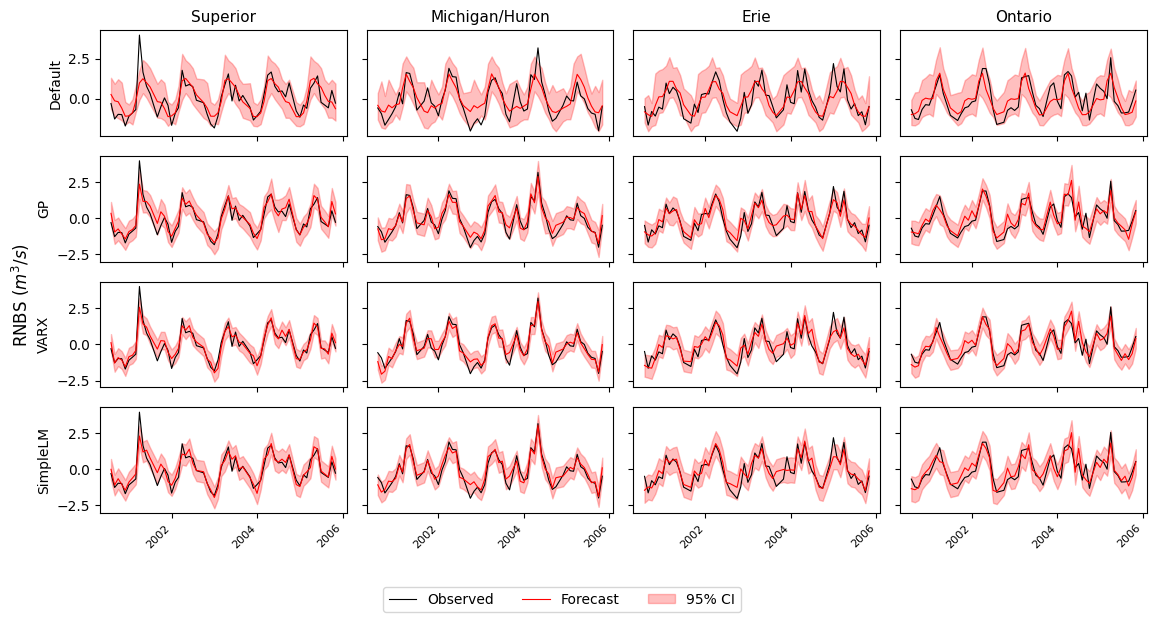

Saved images/model_comparison.pdf


In [53]:
LAKE_ORDER = ["sup", "mic_hur", "eri", "ont"]
MODEL_ORDER = ["Default", "GP_Matern", "VARX", "SimpleLM", "NARX"]
LABEL_MAP = {
    "sup": "Superior",
    "mic_hur": "Michigan/Huron",
    "eri": "Erie",
    "ont": "Ontario",
    "GP_Matern": "GP",
}


def facet_rename(x):
    return LABEL_MAP.get(x, x)


unscaled_plot_data = scaled_data[
    (scaled_data["model"].isin(MODEL_ORDER)) & (scaled_data["split"] >= 6)
].copy()

models_present = [m for m in MODEL_ORDER if m in unscaled_plot_data["model"].unique()]
lakes_present = [l for l in LAKE_ORDER if l in unscaled_plot_data["lake"].unique()]

fig, axs = plt.subplots(
    len(models_present),
    len(lakes_present),
    figsize=(12, 6),
    sharex=True,
    sharey="row",
)
axs = np.atleast_2d(axs)

for row, model in enumerate(models_present):
    for col, lake in enumerate(lakes_present):
        ax = axs[row, col]
        subset = unscaled_plot_data[
            (unscaled_plot_data["model"] == model)
            & (unscaled_plot_data["lake"] == lake)
        ].sort_values("Date")

        ax.plot(subset["Date"], subset["true"], color="black", lw=0.8, label="Observed")
        ax.plot(subset["Date"], subset["mean"], color="red", lw=0.8, label="Forecast")
        ax.fill_between(
            subset["Date"],
            subset["lower"],
            subset["upper"],
            color="red",
            alpha=0.25,
            label="95% CI",
        )

        if row == 0:
            ax.set_title(facet_rename(lake), fontsize=11)
        if col == 0:
            ax.set_ylabel(facet_rename(model), fontsize=10)

        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)

fig.text(0.04, 0.5, r"RNBS $(m^3/s)$", va="center", rotation="vertical", fontsize=12)

handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.04))

fig.tight_layout(rect=[0.05, 0.05, 1, 1])
fig.savefig(IMAGES_DIR / "model_comparison.pdf")
plt.show()
print(f"Saved {IMAGES_DIR / 'model_comparison.pdf'}")

## Figure: Autoregressive Term Comparison

Reload each saved pkl, re-run `predictive_fn_` to draw from the full posterior predictive
(not just the marginal N(mean, std)), and compute per-draw RMSE.

This may take a few minutes — each call draws 500 samples for 13 forecast steps.

In [35]:
import dill
from jax.random import PRNGKey
from jax import numpy as jnp
from sklearn.model_selection import TimeSeriesSplit
from tqdm.auto import tqdm

os.environ["JAX_PLATFORM_NAME"] = "cpu"

AR_MODELS = ["VARX", "NARX_lag1", "VARX_lag2", "VARX_lag3"]
FORECAST_STEPS = 13
LAKE_NAMES = ["sup", "mic_hur", "eri", "ont"]

# Mirror the data setup from 02_fit_models.py
lake_data = xr.open_dataarray("data/lake_data.nc")
train_data = lake_data.sel(Date=slice(None, "2005"))
X_full = train_data.sel(variable=["precip", "temp", "evap"]).drop_vars("type")
y_raw = train_data.sel(variable=["rnbs"]).squeeze().drop_vars(["type", "variable"])
y_full = y_scaler.transform(y_raw)

splitter = TimeSeriesSplit(n_splits=10, test_size=FORECAST_STEPS, gap=0)
splits = list(splitter.split(train_data))

chunks = []
for model_name in tqdm(
    AR_MODELS, desc="Predicting with AR models", unit="model", position=0
):
    for split_i, (train_id, test_id) in tqdm(
        enumerate(splits),
        desc=f"{model_name} CV splits",
        unit="split",
        position=1,
        total=10,
    ):
        pkl_path = MODEL_DIR / f"{model_name}_{split_i}.pkl"
        with open(pkl_path, "rb") as f:
            pipeline = dill.load(f)

        varx = pipeline.named_steps["model"]

        # Scale X through the same pipeline step that was used at fit time
        X_sub = X_full[: max(test_id) + 1]
        X_scaled = pipeline.named_steps["preprocess"].transform(X_sub)
        y_sub = y_full[: max(test_id) + 1]

        months = jnp.array(y_sub.indexes["Date"].month - 1)
        covariates = {
            str(v): jnp.array(X_scaled.sel(variable=str(v)).values)
            for v in X_scaled.coords["variable"].values
        }

        # forecast_marginal: (n_samples, FORECAST_STEPS, 4_lakes)
        fm = np.array(
            varx.predictive_fn_(
                PRNGKey(split_i),
                y=jnp.array(y_sub),
                months=months,
                covariates=covariates,
                lags=varx.lags,
                future=FORECAST_STEPS,
            )["y_forecast"]
        )

        # True values for this split: (FORECAST_STEPS, 4_lakes)
        y_true = y_full.isel(Date=list(test_id)).values

        # Squared error per (sample, months_ahead, lake): (n_samples, FORECAST_STEPS, 4)
        sq_err = (fm - y_true[None, :, :]) ** 2

        n_samples = fm.shape[0]
        s_idx, t_idx, l_idx = np.meshgrid(
            np.arange(n_samples),
            np.arange(1, FORECAST_STEPS + 1),
            np.arange(4),
            indexing="ij",
        )
        chunks.append(
            pd.DataFrame(
                {
                    "model": model_name,
                    "split": split_i,
                    "months_ahead": t_idx.ravel(),
                    "lake": np.array(LAKE_NAMES)[l_idx.ravel()],
                    "rmse": np.sqrt(sq_err).ravel(),
                }
            )
        )

ar_sim_data = pd.concat(chunks, ignore_index=True)
ar_sim_data = ar_sim_data[ar_sim_data["months_ahead"] <= 12]

Predicting with AR models:   0%|          | 0/4 [00:00<?, ?model/s]

VARX CV splits:   0%|          | 0/10 [00:00<?, ?split/s]

KeyError: slice(1, None, None)

In [ ]:
from matplotlib.patches import Patch

MODEL_ORDER = ["VARX", "VARX_lag2", "VARX_lag3", "NARX_lag1"]
MODEL_LABELS = {
    "VARX": "VARX (lag 1)",
    "VARX_lag2": "VARX (lag 2)",
    "VARX_lag3": "VARX (lag 3)",
    "NARX_lag1": "NARX (lag 1)",
}
palette = {
    "VARX": "#2171b5",
    "VARX_lag2": "#6baed6",
    "VARX_lag3": "#bdd7e7",
    "NARX_lag1": "#d94801",
}

months = sorted(ar_sim_data["months_ahead"].unique())
n_months = len(months)
n_models = len(MODEL_ORDER)
group_w = 0.8
box_w = group_w / n_models * 0.9
offsets = (np.arange(n_models) - (n_models - 1) / 2) * (group_w / n_models)

lake_list = [l for l in LAKE_NAMES if l in ar_sim_data["lake"].unique()]
nrows, ncols = 2, 2

fig, axs = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(14, 10),
    sharey=True,
    gridspec_kw={"hspace": 0.15, "wspace": 0.08},
)
axs = axs.flatten()

for i, lake in enumerate(lake_list):
    ax = axs[i]
    subset = ar_sim_data[ar_sim_data["lake"] == lake]

    for m_idx, model in enumerate(MODEL_ORDER):
        color = palette[model]
        model_subset = subset[subset["model"] == model]
        positions = [t + offsets[m_idx] for t in range(1, n_months + 1)]
        data_arrays = [
            model_subset[model_subset["months_ahead"] == m]["rmse"].values
            for m in months
        ]
        ax.boxplot(
            data_arrays,
            positions=positions,
            widths=box_w,
            patch_artist=True,
            showfliers=False,
            showcaps=False,
            whis=1.5,
            boxprops=dict(facecolor=color, alpha=0.7, linewidth=1.0),
            whiskerprops=dict(color="black", linewidth=0.5, alpha=0.35),
            medianprops=dict(color="black"),
        )

    ax.set_title(facet_rename(lake), fontsize=12)
    ax.set_xticks(range(1, n_months + 1))
    ax.set_xticklabels(months)
    ax.set_xlabel("")

for j in range(i + 1, nrows * ncols):
    fig.delaxes(axs[j])

axs[0].set_ylim(-0.05, np.percentile(ar_sim_data["rmse"], 99.95))

fig.text(0.5, 0.06, "Months Ahead", ha="center", va="center", fontsize=14)
fig.text(0.08, 0.5, "RMSE", ha="center", va="center", rotation="vertical", fontsize=14)

legend_handles = [
    Patch(facecolor=palette[m], alpha=0.7, label=MODEL_LABELS[m]) for m in MODEL_ORDER
]
fig.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(0.95, 0.5),
    ncol=1,
)

plt.tight_layout(rect=[0.04, 0.02, 0.88, 0.98])
plt.savefig(str(IMAGES_DIR / "ar_comparison.pdf"), bbox_inches="tight")
plt.show()

NameError: name 'ar_sim_data' is not defined

## Figure: VARX Posterior Correlation Matrix

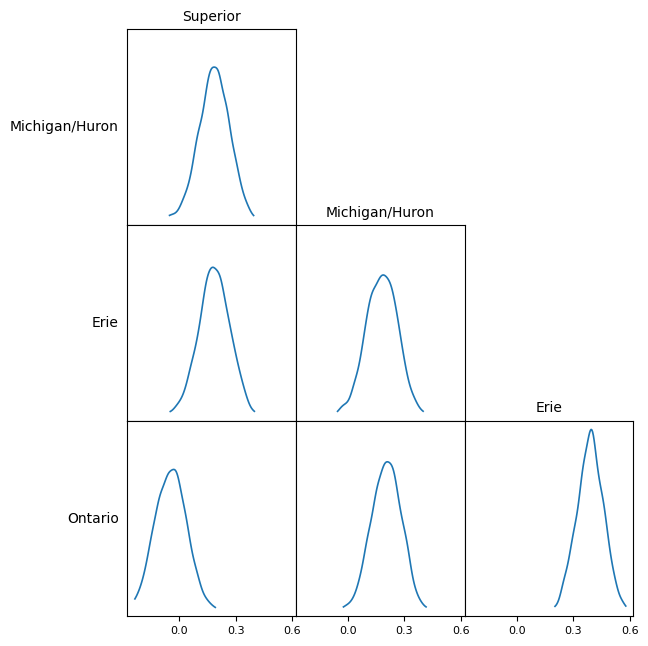

Saved images/correlation_matrices.pdf


In [36]:
from scipy.stats import gaussian_kde
import dill

valid_set = [
    ("mic_hur", "sup"),
    ("eri", "sup"),
    ("eri", "mic_hur"),
    ("ont", "sup"),
    ("ont", "mic_hur"),
    ("ont", "eri"),
]

fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(9, 9), sharex=True, sharey=True)
axs = axs.flatten()

triangle_plots = [4, 8, 9, 12, 13, 14]
valid_pairs = valid_set.copy()

with open(MODEL_DIR / "VARX_0.pkl", "rb") as f:
    pipeline = dill.load(f)
varx = pipeline.named_steps["model"]
trace = varx.trace_

# fix this - missing proper variable names; use the order from 02_fit_models.py (hacky, but can't be skipped!)
coord_order = ["precip", "temp", "evap"]
trace.posterior.coords["variable"] = coord_order


for idx in range(16):
    ax = axs[idx]

    if idx not in triangle_plots:
        ax.set_visible(False)
        continue

    series, lake = valid_pairs.pop(0)
    subtrace = trace.posterior["corr"].sel(series=series, lakes=lake)

    data = subtrace.values.flatten()
    kde = gaussian_kde(data)

    lo, hi = -0.1, 0.8  # np.percentile(data, [0.5, 99.5])
    pad = (hi - lo) * 0.15
    xs = np.linspace(lo - pad, hi + pad, 300)
    ys = kde(xs)

    mask = ys > ys.max() * 0.02
    ax.plot(xs[mask], ys[mask], linewidth=1.2)
    # ax.set_xlim(xs[mask][0], xs[mask][-1])

    ax.set_yticks([])
    ax.set_ylabel("")
    ax.set_xlabel("")

    row = idx // 4
    col = idx % 4

    if row == 3:
        ax.xaxis.set_major_locator(plt.MaxNLocator(3))
        ax.tick_params(axis="x", labelsize=8)
    else:
        ax.set_xticks([])

    if row == col + 1:
        ax.set_title(rename_lakes(lake), fontsize=10, pad=6)

    if col == 0:
        ax.annotate(
            rename_lakes(series),
            xy=(0, 0.5),
            xycoords="axes fraction",
            ha="right",
            va="center",
            fontsize=10,
            xytext=(-6, 0),
            textcoords="offset points",
        )

plt.subplots_adjust(
    wspace=0.0, hspace=0.0, left=0.20, right=0.95, top=0.95, bottom=0.08
)
plt.savefig(str(IMAGES_DIR / "correlation_matrices.pdf"), bbox_inches="tight")
plt.show()
print(f"Saved {IMAGES_DIR / 'correlation_matrices.pdf'}")


## Figure: VARX Trace Plot

/var/folders/lb/h2cbp3cd179gwfsz_c6b9kk80000gq/T/ipykernel_22919/2533533695.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 1])


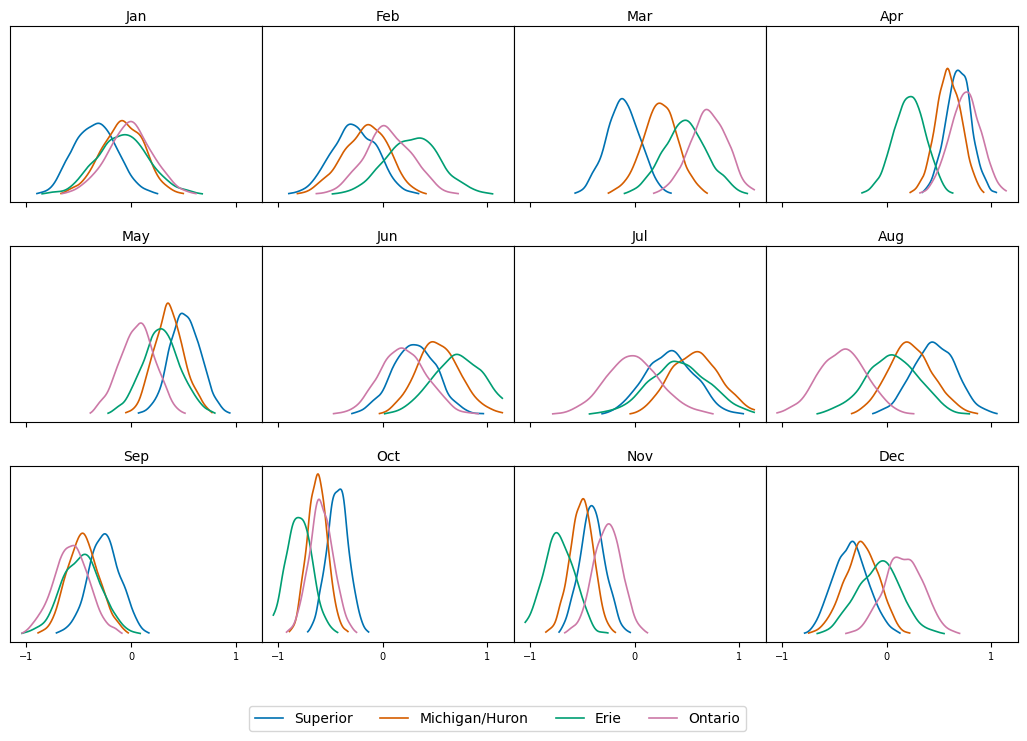

In [37]:
from scipy.stats import gaussian_kde
import calendar

month_names = list(calendar.month_abbr)[1:]
lake_colors = {
    "sup": "#0072B2",  # blue
    "mic_hur": "#D55E00",  # vermillion
    "eri": "#009E73",  # bluish green
    "ont": "#CC79A7",  # reddish purple
}


intercept = trace.posterior["intercept"]

# global x range across all months and lakes
all_vals = intercept.values.flatten()
lo, hi = np.percentile(all_vals, [0.5, 99.5])
pad = (hi - lo) * 0.05
xs = np.linspace(lo - pad, hi + pad, 400)

nrows, ncols = 3, 4
fig, axs = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(13, 8),
    sharex=True,
    sharey=True,
    gridspec_kw={"hspace": 0.25, "wspace": 0.0},
)
axs = axs.flatten()

for m_idx, month in enumerate(month_names):
    ax = axs[m_idx]
    for lake in LAKE_NAMES:
        data = intercept.sel(month=month, lakes=lake).values.flatten()
        kde = gaussian_kde(data)
        ys = kde(xs)
        mask = ys > ys.max() * 0.02
        ax.plot(
            xs[mask],
            ys[mask],
            color=lake_colors[lake],
            label=rename_lakes(lake),
            linewidth=1.2,
        )

    ax.set_title(month, fontsize=10, pad=4)
    ax.set_yticks([])

for ax in axs[-ncols:]:
    ax.xaxis.set_major_locator(plt.MaxNLocator(3))
    ax.tick_params(axis="x", labelsize=7)

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.01),
    fontsize=10,
)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(str(IMAGES_DIR / "intercept_posteriors.pdf"), bbox_inches="tight")
plt.show()


In [38]:
trace.posterior["covar_alphas"]

<xarray.DataArray 'covar_alphas' (chain: 4, draw: 500, covariate: 3, series: 4,
                                  lakes: 4)> Size: 384kB
array([[[[[ 5.15957773e-01, -3.02609405e-05, -1.83919176e-01,
            8.65216628e-02],
          [-2.36926954e-02,  4.95080471e-01,  6.11380376e-02,
           -1.31270988e-02],
          [ 2.03847252e-02, -1.03849806e-01,  4.62024122e-01,
            2.06923574e-01],
          [-1.66798346e-02,  1.02908053e-01, -7.96219036e-02,
            5.11287510e-01]],

         [[-1.21789306e-01,  1.55770376e-01,  7.61981159e-02,
            1.03253663e-01],
          [-4.49127346e-01,  2.81188101e-01,  5.73385835e-01,
           -1.90199651e-02],
          [-2.28803113e-01,  2.99177200e-01, -8.76183987e-01,
            1.02625763e+00],
          [ 4.45810854e-02,  6.30493343e-01, -1.14544189e+00,
            8.38879466e-01]],

         [[-1.76610187e-01, -2.68725842e-01,  2.53334552e-01,
            5.06412201e-02],
...
          [-5.52618764e-02,  1.09763844e-02, -3.16528417e-02,
            5.00570416e-01]],

         [[-3.46805066e-01,  7.86189020e-01, -1.76830649e-01,
           -9.16442871e-02],
          [-7.38687888e-02, -4.01538491e-01,  7.88615644e-01,
           -1.23449653e-01],
          [ 2.23249674e-01, -8.80970955e-01,  6.64207876e-01,
            2.96561420e-03],
          [ 2.20696166e-01, -2.69157022e-01, -1.26775384e-01,
            5.85332692e-01]],

         [[-2.23427892e-01, -2.33883798e-01,  6.35526925e-02,
            1.93423733e-01],
          [-1.27716467e-01, -4.79767144e-01, -1.52071625e-01,
            2.96964616e-01],
          [ 1.01790532e-01, -3.31389964e-01, -1.37443677e-01,
           -1.96959108e-01],
          [-7.32041616e-03, -1.44453958e-01,  4.65293676e-02,
           -3.08715612e-01]]]]], shape=(4, 500, 3, 4, 4), dtype=float32)
Coordinates:
  * chain      (chain) int64 32B 0 1 2 3
  * draw       (draw) int64 4kB 0 1 2 3 4 5 6 7 ... 493 494 495 496 497 498 499
  * covariate  (covariate) <U6 72B 'precip' 'temp' 'evap'
  * series     (series) <U7 112B 'sup' 'mic_hur' 'eri' 'ont'
  * lakes      (lakes) <U7 112B 'sup' 'mic_hur' 'eri' 'ont'

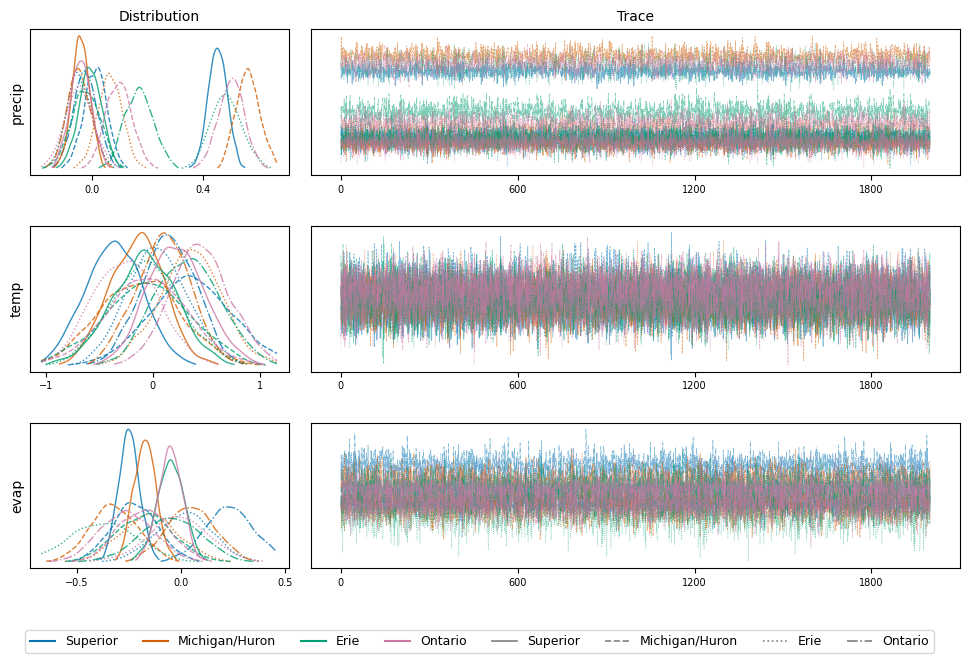

In [39]:
from scipy.stats import gaussian_kde

x_alpha = trace.posterior["covar_alphas"]  # (chain, draw, variable, lakes)
covariate_names_raw = varx.cov_names_


chain_styles = ["-", "--", ":", "-."]
n_chains = x_alpha.chain.size

fig, axs = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(12, 7),
    gridspec_kw={"wspace": 0.05, "hspace": 0.35, "width_ratios": [1, 2.5]},
)

for r_idx, cov in enumerate(covariate_names_raw):
    ax_kde = axs[r_idx, 0]
    ax_trace = axs[r_idx, 1]

    all_vals = x_alpha.sel(covariate=cov).values.flatten()
    lo, hi = np.percentile(all_vals, [0.5, 99.5])
    pad = (hi - lo) * 0.05
    xs = np.linspace(lo - pad, hi + pad, 400)

    for lake in LAKE_NAMES:
        color = lake_colors[lake]
        x_alpha.sel(covariate=cov)
        for c_idx, lake_in in enumerate(LAKE_NAMES):
            data = (
                x_alpha.sel(
                    covariate=cov,
                    series=lake,
                    lakes=lake_in,
                )
                .stack(samples=("chain", "draw"))
                .transpose("samples", ...)
                .values
            )
            ls = chain_styles[c_idx]

            ys = gaussian_kde(data)(xs)
            mask = ys > ys.max() * 0.02
            ax_kde.plot(
                xs[mask], ys[mask], color=color, linestyle=ls, linewidth=1.0, alpha=0.8
            )

            ax_trace.plot(data, color=color, linestyle=ls, linewidth=0.5, alpha=0.5)

    ax_kde.set_yticks([])
    ax_kde.set_ylabel(cov, fontsize=10)
    ax_kde.xaxis.set_major_locator(plt.MaxNLocator(3))
    ax_kde.tick_params(axis="x", labelsize=7)

    ax_trace.set_yticks([])
    ax_trace.xaxis.set_major_locator(plt.MaxNLocator(4))
    ax_trace.tick_params(axis="x", labelsize=7)

    if r_idx == 0:
        ax_kde.set_title("Distribution", fontsize=10)
        ax_trace.set_title("Trace", fontsize=10)

lake_handles = [
    plt.Line2D([0], [0], color=lake_colors[l], linewidth=1.5, label=rename_lakes(l))
    for l in LAKE_NAMES
]
chain_handles = [
    plt.Line2D(
        [0],
        [0],
        color="gray",
        linestyle=chain_styles[i],
        linewidth=1.2,
        label=rename_lakes(lake_in),
    )
    for i, lake_in in enumerate(LAKE_NAMES)
]
fig.legend(
    handles=lake_handles + chain_handles,
    loc="lower center",
    ncol=len(LAKE_NAMES) + n_chains,
    bbox_to_anchor=(0.5, -0.02),
    fontsize=9,
)
plt.savefig(str(IMAGES_DIR / "x_alpha_trace.pdf"), bbox_inches="tight")
plt.show()


In [41]:
trace.posterior

<xarray.DataTree 'posterior'>
Group: /posterior
    Dimensions:                     (chain: 4, draw: 500, series: 4, lakes: 4,
                                     covariate: 3, month: 12,
                                     intercept_decentered_dim_0: 12,
                                     intercept_decentered_dim_1: 4,
                                     l_omega_dim_0: 4, l_omega_dim_1: 4, lag: 1,
                                     variable: 3)
    Coordinates:
      * chain                       (chain) int64 32B 0 1 2 3
      * draw                        (draw) int64 4kB 0 1 2 3 4 ... 496 497 498 499
      * series                      (series) <U7 112B 'sup' 'mic_hur' 'eri' 'ont'
      * lakes                       (lakes) <U7 112B 'sup' 'mic_hur' 'eri' 'ont'
      * covariate                   (covariate) <U6 72B 'precip' 'temp' 'evap'
      * month                       (month) <U3 144B 'Jan' 'Feb' ... 'Nov' 'Dec'
      * intercept_decentered_dim_0  (intercept_decentered_dim_0) int64 96B 0 ... 11
      * intercept_decentered_dim_1  (intercept_decentered_dim_1) int64 32B 0 1 2 3
      * l_omega_dim_0               (l_omega_dim_0) int64 32B 0 1 2 3
      * l_omega_dim_1               (l_omega_dim_1) int64 32B 0 1 2 3
      * lag                         (lag) int64 8B 1
      * variable                    (variable) <U6 72B 'precip' 'temp' 'evap'
    Data variables:
        corr                        (chain, draw, series, lakes) float32 128kB 1....
        covar_alphas                (chain, draw, covariate, series, lakes) float32 384kB ...
        global_mu                   (chain, draw) float32 8kB -0.05048 ... -0.002351
        intercept                   (chain, draw, month, lakes) float32 384kB -0....
        intercept_decentered        (chain, draw, intercept_decentered_dim_0, intercept_decentered_dim_1) float32 384kB ...
        l_omega                     (chain, draw, l_omega_dim_0, l_omega_dim_1) float32 128kB ...
        nu                          (chain, draw) float32 8kB 14.13 6.905 ... 10.72
        theta                       (chain, draw, lakes) float32 32kB 0.1082 ... ...
        y_alphas                    (chain, draw, lag, series, lakes) float32 128kB ...
    Attributes:
        created_at:                 2026-07-13T15:34:33.602634+00:00
        creation_library:           ArviZ
        creation_library_version:   1.1.0
        creation_library_language:  Python
        inference_library:          numpyro
        inference_library_version:  0.21.0
        sample_dims:                ['chain', 'draw']

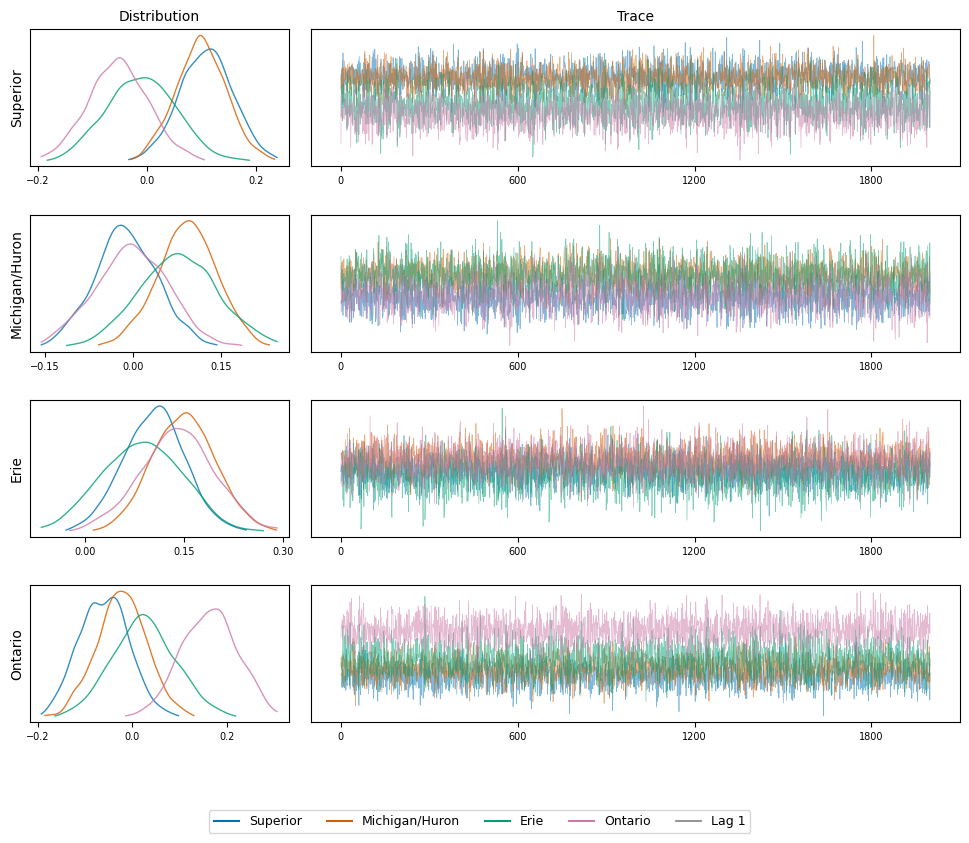

In [42]:
from scipy.stats import gaussian_kde

y_alpha = trace.posterior["y_alphas"]  # (chain, draw, lag, series, lakes)

n_lags = y_alpha.lag.size
lag_styles = ["-", "--", ":", "-."][:n_lags]

fig, axs = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(12, 9),
    gridspec_kw={"wspace": 0.05, "hspace": 0.35, "width_ratios": [1, 2.5]},
)

for r_idx, target_lake in enumerate(LAKE_NAMES):
    ax_kde = axs[r_idx, 0]
    ax_trace = axs[r_idx, 1]

    all_vals = y_alpha.sel(lakes=target_lake).values.flatten()
    lo, hi = np.percentile(all_vals, [0.5, 99.5])
    pad = (hi - lo) * 0.05
    xs = np.linspace(lo - pad, hi + pad, 400)

    for source_lake in LAKE_NAMES:
        color = lake_colors[source_lake]
        for l_idx, lag in enumerate(y_alpha.lag.values):
            data = (
                y_alpha.sel(lakes=target_lake, series=source_lake, lag=lag)
                .stack(samples=("chain", "draw"))
                .transpose("samples", ...)
                .values
            )
            ls = lag_styles[l_idx]
            ys = gaussian_kde(data)(xs)
            mask = ys > ys.max() * 0.02
            ax_kde.plot(
                xs[mask], ys[mask], color=color, linestyle=ls, linewidth=1.0, alpha=0.8
            )
            ax_trace.plot(data, color=color, linestyle=ls, linewidth=0.5, alpha=0.5)

    ax_kde.set_yticks([])
    ax_kde.set_ylabel(rename_lakes(target_lake), fontsize=10)
    ax_kde.xaxis.set_major_locator(plt.MaxNLocator(3))
    ax_kde.tick_params(axis="x", labelsize=7)
    ax_trace.set_yticks([])
    ax_trace.xaxis.set_major_locator(plt.MaxNLocator(4))
    ax_trace.tick_params(axis="x", labelsize=7)

    if r_idx == 0:
        ax_kde.set_title("Distribution", fontsize=10)
        ax_trace.set_title("Trace", fontsize=10)

lake_handles = [
    plt.Line2D([0], [0], color=lake_colors[l], linewidth=1.5, label=rename_lakes(l))
    for l in LAKE_NAMES
]
lag_handles = [
    plt.Line2D(
        [0],
        [0],
        color="gray",
        linestyle=lag_styles[i],
        linewidth=1.2,
        label=f"Lag {lag}",
    )
    for i, lag in enumerate(y_alpha.lag.values)
]
fig.legend(
    handles=lake_handles + lag_handles,
    loc="lower center",
    ncol=len(LAKE_NAMES) + n_lags,
    bbox_to_anchor=(0.5, -0.02),
    fontsize=9,
)
plt.savefig(str(IMAGES_DIR / "y_alpha_trace.pdf"), bbox_inches="tight")
plt.show()

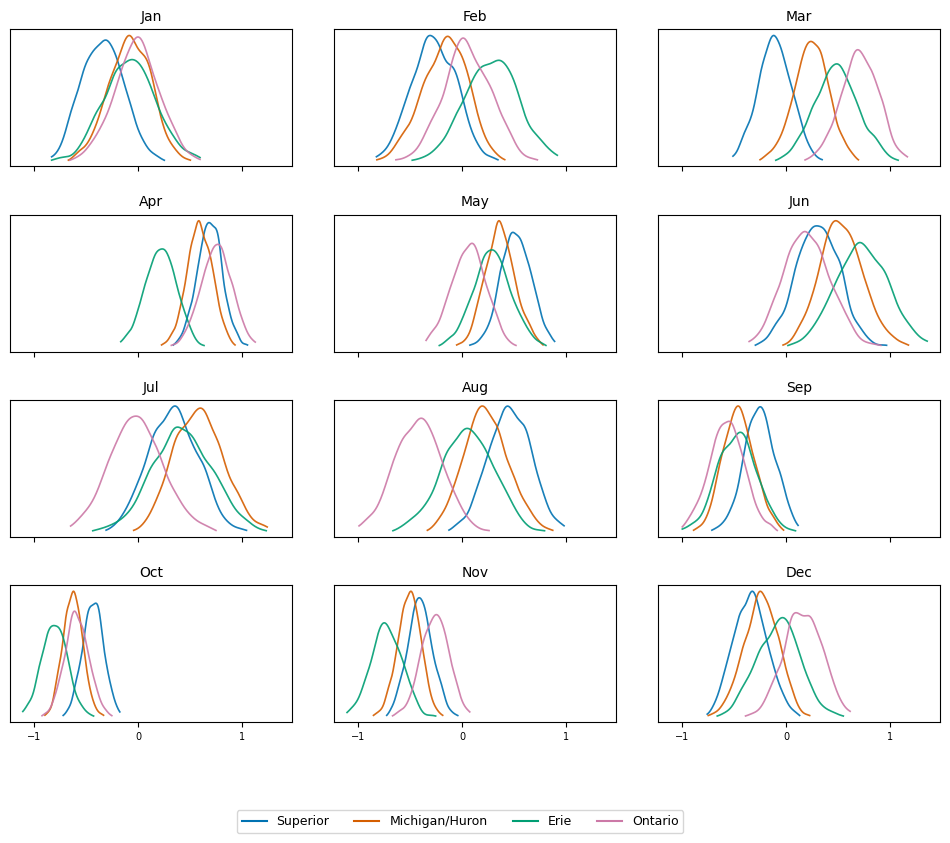

In [43]:
from scipy.stats import gaussian_kde

intercept = trace.posterior["intercept"]  # (chain, draw, month, lakes)

fig, axs = plt.subplots(
    nrows=4,
    ncols=3,
    figsize=(12, 9),
    gridspec_kw={"wspace": 0.15, "hspace": 0.35},
    sharex=True,
)

for m_idx, month in enumerate(month_names):
    ax = axs[m_idx // 3, m_idx % 3]

    all_vals = intercept.sel(month=month).values.flatten()
    lo, hi = np.percentile(all_vals, [0.5, 99.5])
    pad = (hi - lo) * 0.05
    xs = np.linspace(lo - pad, hi + pad, 400)

    for lake in LAKE_NAMES:
        data = (
            intercept.sel(lakes=lake, month=month)
            .stack(samples=("chain", "draw"))
            .values
        )
        ys = gaussian_kde(data)(xs)
        mask = ys > ys.max() * 0.02
        ax.plot(xs[mask], ys[mask], color=lake_colors[lake], linewidth=1.2, alpha=0.9)

    ax.set_yticks([])
    ax.set_title(month, fontsize=10)
    ax.xaxis.set_major_locator(plt.MaxNLocator(3))
    ax.tick_params(axis="x", labelsize=7)

lake_handles = [
    plt.Line2D([0], [0], color=lake_colors[l], linewidth=1.5, label=rename_lakes(l))
    for l in LAKE_NAMES
]
fig.legend(
    handles=lake_handles,
    loc="lower center",
    ncol=len(LAKE_NAMES),
    bbox_to_anchor=(0.5, -0.02),
    fontsize=9,
)
plt.savefig(str(IMAGES_DIR / "intercept_posteriors.pdf"), bbox_inches="tight")
plt.show()

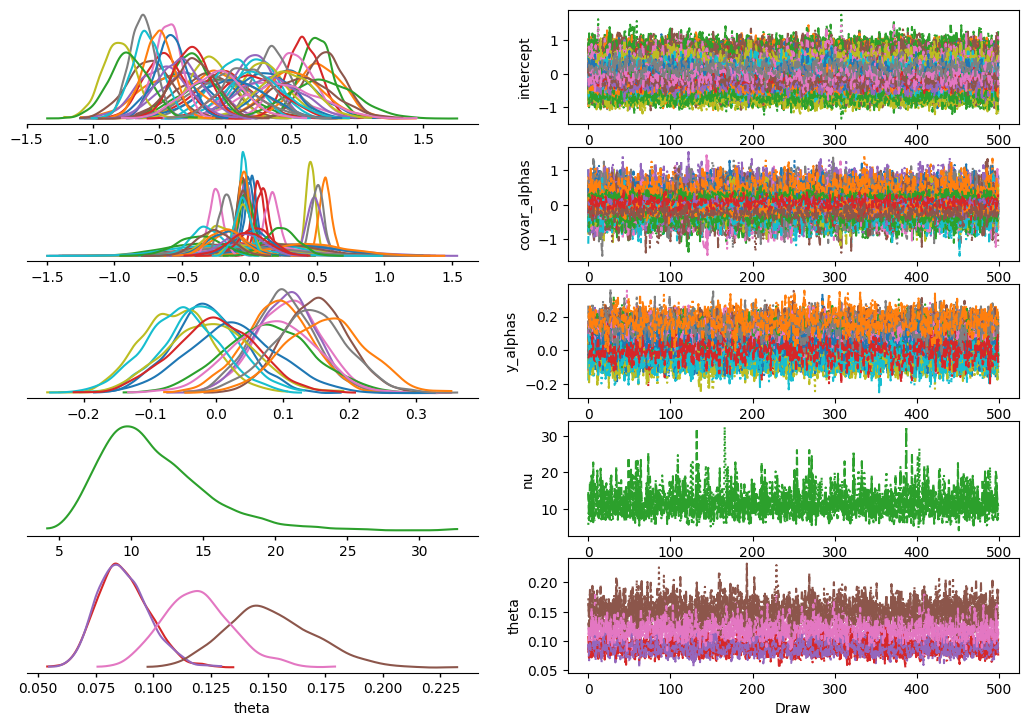

In [45]:
az.plot_trace_dist(
    trace,
    var_names=[
        "intercept",
        "covar_alphas",
        "y_alphas",
        "nu",
        "theta",
    ],
    combined=True,
    # rows=["lakes"]
)

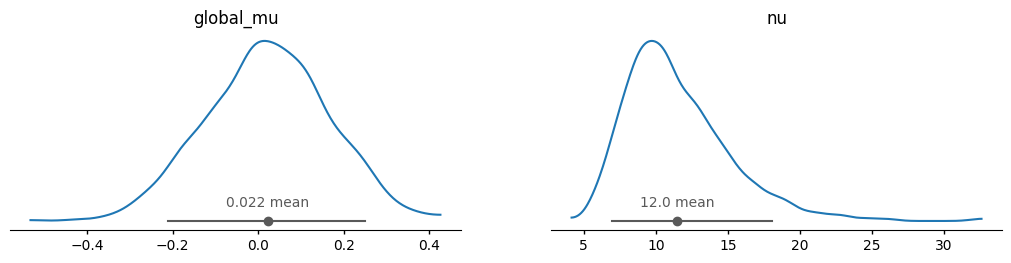

In [47]:
az.plot_dist(trace, var_names=["global_mu", "nu"])

In [49]:
az.summary(trace, var_names=["y_alphas"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
"y_alphas[1, sup, sup]",0.109,0.05,0.03,0.19,2404,1493,1.00,0.001,0.00071
"y_alphas[1, sup, mic_hur]",-0.012,0.053,-0.099,0.075,2376,1677,1.00,0.0011,0.00075
"y_alphas[1, sup, eri]",0.105,0.047,0.027,0.18,2453,1717,1.00,0.00095,0.00069
"y_alphas[1, sup, ont]",-0.06,0.053,-0.14,0.024,2406,1590,1.00,0.0011,0.00076
"y_alphas[1, mic_hur, sup]",0.099,0.047,0.022,0.17,1883,1492,1.00,0.0011,0.00076
"y_alphas[1, mic_hur, mic_hur]",0.092,0.051,0.0076,0.17,2058,1648,1.00,0.0011,0.00078
"y_alphas[1, mic_hur, eri]",0.15,0.049,0.073,0.23,2334,1686,1.00,0.001,0.00072
"y_alphas[1, mic_hur, ont]",-0.023,0.054,-0.11,0.062,2300,1747,1.00,0.0011,0.00079
"y_alphas[1, eri, sup]",-0.011,0.065,-0.11,0.092,2429,1445,1.00,0.0013,0.00093
"y_alphas[1, eri, mic_hur]",0.078,0.068,-0.031,0.19,2472,1752,1.00,0.0014,0.00095


# Interval calibration curves